In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yapss
from yapss import math
import sympy as sp

problem = yapss.Problem(name="Simple_Cycler", nx=[4], nd = 4)
mu = 1.2150584270572e-2

In [2]:
def objective(arg):
    # arg.objective = arg.phase[0].final_time
    arg.objective = 0

def continuous(arg):
    x, y, vx, vy = arg.phase[0].state
    r1 = math.sqrt((x + mu)**2 + y**2)
    r2 = math.sqrt((x - 1 + mu)**2 + y**2)
    ax = x - (1 - mu)*(x + mu)/r1**3 - mu*(x - 1 + mu)/r2**3 + 2*vy
    ay = y - (1 - mu)*y/r1**3 - mu*y/r2**3 - 2*vx

    arg.phase[0].dynamics = [vx, vy, ax, ay]

def discrete(arg):
    xi, yi, vxi, vyi = arg.phase[0].initial_state
    xf, yf, vxf, vyf = arg.phase[0].final_state
    arg.discrete = [xf-xi, yf-yi, vxf-vxi, vyf-vyi]

In [3]:
problem.functions.objective = objective
problem.functions.continuous = continuous
problem.functions.discrete = discrete

In [4]:
def U_derivs():
    x, y = sp.symbols('x y', real = True)

    r1 = sp.sqrt((x + mu)**2 + y**2)
    r2 = sp.sqrt((x - 1 + mu)**2 + y**2)

    U = -0.5*(x**2 + y**2) - (1 - mu)/r1 - mu/r2

    Ux  = sp.diff(U, x)
    Uy  = sp.diff(U, y)

    Uxx = sp.diff(Ux, x)
    Uxy = sp.diff(Ux, y)
    Uyy = sp.diff(Uy, y)

    U_f = sp.lambdify((x, y), U, "numpy")
    Ux_f = sp.lambdify((x, y), Ux, "numpy")
    Uy_f = sp.lambdify((x, y), Uy, "numpy")
    Uxx_f = sp.lambdify((x, y), Uxx, "numpy")
    Uxy_f = sp.lambdify((x, y), Uxy, "numpy")
    Uyy_f = sp.lambdify((x, y), Uyy, "numpy")

    return U_f, Ux_f, Uy_f, Uxx_f, Uxy_f, Uyy_f

U, Ux, Uy, Uxx, Uxy, Uyy = U_derivs()

def y_dot_initial(x, y, C):
    return -math.sqrt(-2*U(x, y) - C)

x_guess = -0.767856324800
C_value = 3.151175879508174
initial_guess = np.array([x_guess, 0, 0, y_dot_initial(x_guess, 0, C_value)])

# import importlib, helper
# importlib.reload(helper)
# helper.initialize(mu, U, Ux, Uy, Uxx, Uxy, Uyy, initial_guess)
# t1, X1, Phi1, sol = helper.integrate_half_period(100)

In [5]:
def day_to_gen(t):
    return t*2*math.pi/27.321661
def gen_to_day(t):
    return t*27.321661/2/math.pi

In [6]:
bounds = problem.bounds.phase[0]
bounds.initial_time.lower = bounds.initial_time.upper = 0
bounds.final_time.lower = day_to_gen(44.7538 - 0.95)
bounds.final_time.upper = day_to_gen(44.7538 + 0.95)
problem.bounds.discrete.lower = problem.bounds.discrete.upper = [0, 0, 0, 0]
bounds.initial_state.lower[1:3] = bounds.initial_state.upper[1:3] = bounds.final_state.lower[1:3] = bounds.final_state.upper[1:3] = [0, 0]

In [7]:
def pixel_convert(pix_in):
    px = pix_in[0]
    py = pix_in[1]
    x = (px - 678)/550
    y = (545 - py)/550
    return math.array([x, y])

In [8]:
pixels = [
    [251, 544],
    [257, 574],
    [279, 607],
    [351, 649],
    [374, 699],
    [462, 754],
    [581, 795],
    [724, 797],
    [853, 755],
    [948, 693],
    [1014, 631],
    [1056, 578],
    [1087, 540],
    [1111, 512],
    [1129, 499],
    [1144, 499],
    [1153, 514],
    [1161, 538],
    [1170, 571],
    [1188, 593],
    [1212, 598],
    [1243, 578],
    [1250, 527],
    [1222, 493],
    [1197, 492],
    [1175, 509],
    [1161, 538],
    [1156, 567],
    [1148, 585],
    [1135, 591],
    [1118, 583],
    [1096, 561],
    [1069, 525],
    [1030, 477],
    [976, 419],
    [892, 355],
    [772, 301],
    [632, 287],
    [500, 317],
    [402, 369],
    [334, 421],
    [290, 466],
    [264, 503],
    [252, 534],
    # [251, 544]
]
xy = math.zeros((len(pixels), 2))
for i in range(len(pixels)):
    xy[i] = pixel_convert(pixels[i])

In [9]:
xy_dot = math.zeros((len(xy), 2))
for i in range(len(xy)):
    if i == 0 or i == len(xy) - 1:
        xy_dot[i] = math.array([0, 0])
    else:
        xy_dot[i] = ((xy[i] - xy[i-1]) + (xy[i+1] - xy[i]))/2

initial_state_guess = math.concatenate([xy, xy_dot], axis=1)
initial_state_guess = math.transpose(initial_state_guess)

In [10]:
phase = problem.guess.phase[0]
tf = day_to_gen(44.7538)
# t = math.linspace(0, tf, num=45, dtype=float)
t = math.linspace(0, tf, num=44, dtype=float)
phase.time = t
phase.state = initial_state_guess

In [11]:
problem.derivatives.method = "auto"
problem.derivatives.order = "second"
problem.spectral_method = "lgl"
segments, points = 30, 30
problem.mesh.phase[0].collocation_points = segments*[points]
problem.mesh.phase[0].fraction = segments*[1/segments]

In [12]:
problem.ipopt_options.mu_strategy = "adaptive"
problem.ipopt_options.print_level = 3
problem.ipopt_options.print_user_options = "yes"
problem.ipopt_options.timing_statistics = "yes"
problem.ipopt_options.output_file = "cycler_orbit.log"
problem.ipopt_options.tol = 1e-100

In [13]:
sol1 = problem.solve()

In [14]:
solution = sol1

In [15]:
state = solution.phase[0].state
time = solution.phase[0].time
t0 = solution.phase[0].initial_time
tf = solution.phase[0].final_time
x, y, vx, vy = state
print("Orbit Period (nondimensional time)", tf)

Orbit Period (nondimensional time) 10.294536278384973


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


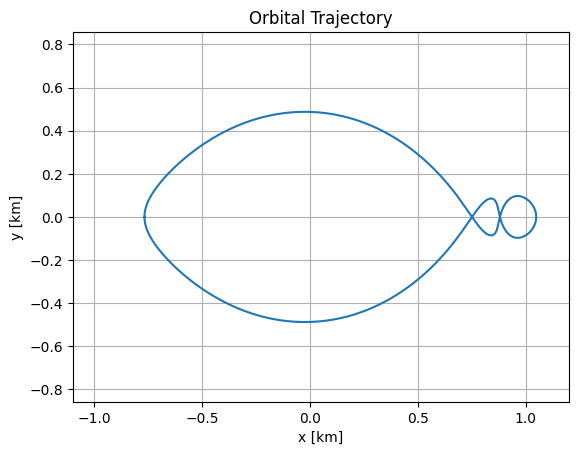

In [16]:
plt.figure()
plt.plot(x, y)
plt.axis("equal")
plt.xlim([-1.1, 1.2])
plt.ylim([-1, 1])
plt.xlabel("x [km]")
plt.ylabel("y [km]")
plt.title("Orbital Trajectory")
plt.grid(True)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


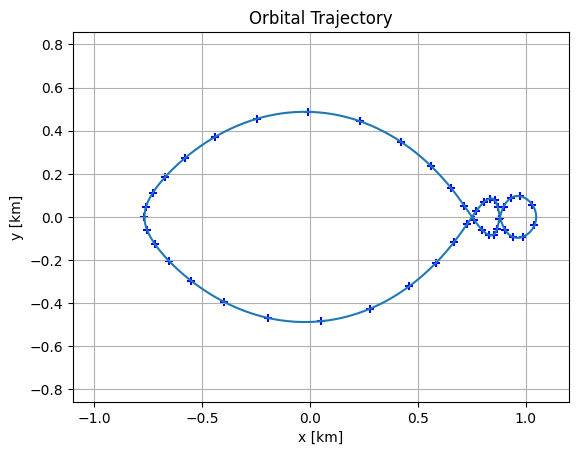

In [17]:
t_tick_days = np.arange(0, 45, 1)
t_tick = day_to_gen(t_tick_days)

from scipy.interpolate import interp1d

fx = interp1d(time, x, kind='cubic', bounds_error=False, fill_value="extrapolate")
fy = interp1d(time, y, kind='cubic', bounds_error=False, fill_value="extrapolate")

x_ticks = fx(t_tick)
y_ticks = fy(t_tick)

plt.figure()
plt.plot(x, y)
plt.axis("equal")
plt.xlim([-1.1, 1.2])
plt.ylim([-1, 1])
plt.xlabel("x [km]")
plt.ylabel("y [km]")
plt.title("Orbital Trajectory")
plt.scatter(x_ticks, y_ticks, marker='+', color='blue')
plt.grid(True)

In [18]:
print("Error [hours]", abs(gen_to_day(tf) - 44.7538)*24)       # hours off from period stated in paper
print("Error [%]", abs(gen_to_day(tf) - 44.7538)/44.7538)  # days off expressed as a percent

Error [hours] 0.25749391680693634
Error [%] 0.00023973189316413388


In [19]:
C_vals = np.zeros((len(x), 1))
for i in range (len(x)):
    C_vals[i] = -2*U(x[i], y[i]) - (vx[i]**2 + vy[i]**2)
C_err = np.ptp(C_vals) # Maximum Jacobi constant deviation\
print("Maximum Jacobi Constant Deviation", C_err)

Maximum Jacobi Constant Deviation 1.865174681370263e-14


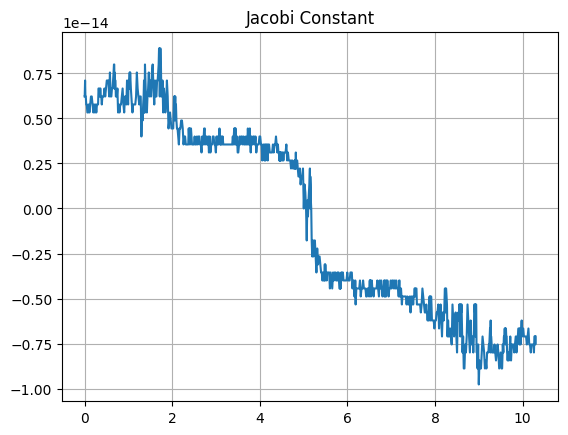

In [20]:
C_mean = np.mean(C_vals)
plt.figure()
plt.plot(time, (C_vals - C_mean))
plt.title("Jacobi Constant")
plt.grid(True)

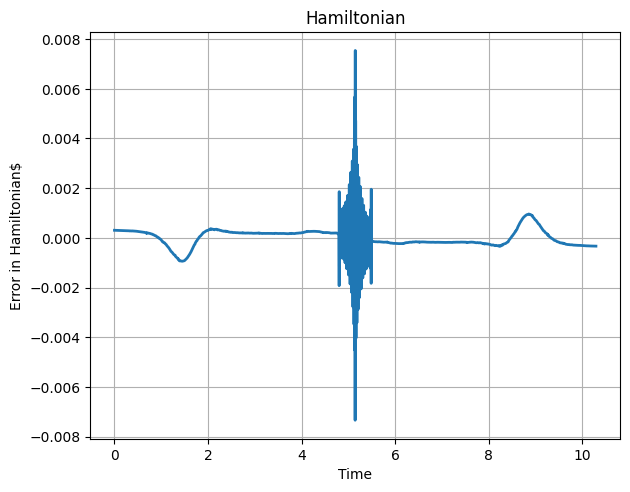

In [21]:
hamiltonian = solution.phase[0].hamiltonian

plt.figure()
plt.plot(time, (hamiltonian), linewidth=2)
plt.xlabel("Time")
plt.ylabel(r"Error in Hamiltonian$")
plt.tight_layout()
plt.title("Hamiltonian")
plt.grid(True)